# Antes de cargar las librerias, hay que instalarlas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.io import loadmat


# Cargamos el data set que deseamos análizar

In [3]:
engine_in = loadmat("datasets/engine/engineInputs.mat")
engine_tar = loadmat("datasets/engine/engineTargets.mat")
#instancias x atributos
engine_in = np.array(engine_in["engineInputs"]).T
engine_tar = np.array(engine_tar["engineTargets"]).T
engine_in.shape, engine_tar.shape

((1199, 2), (1199, 2))

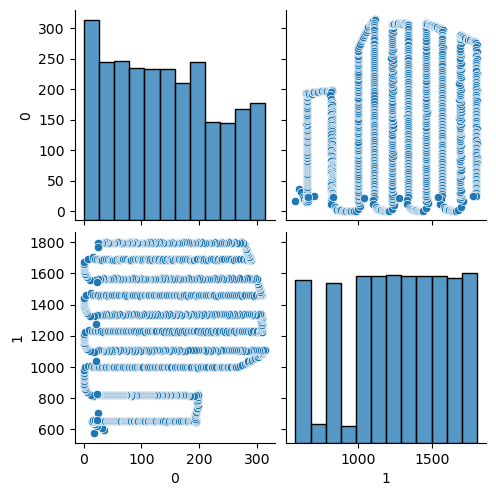

In [9]:
# 0 es el target en este dataset
sns.pairplot(pd.DataFrame(engine_in))
plt.show()

In [10]:
atributos = engine_in.copy()
target = engine_tar.copy()
atributos.shape, target.shape


((1199, 2), (1199, 2))

### Generamos el mejor numero de reglas para el  FIS inicial en  base a los datos

In [11]:
from utils import CrearFISInicial, GuardarFIS
import torch # tensores y demás de pytorch
from sklearn.model_selection import train_test_split
#
from anfislm.V2_Anfis import LevenberMaquardtOpt, train_nfs, RLANFISBuilder, Optimizador
from utils import PrintLogLevel

/Users/omarzamarron/Documents/Artuculos/colab_sukey_survey_andfis/ANFISLMRL/utils/Anfis_utils.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  a = (rango[e,1] - rango[e, 0])/2/(mf_n[e] - 1);


Cargando FIS
Entradas: 2 Salidas: 2 Reglas:1
sigma: torch.Size([2, 1])
centro: torch.Size([2, 1])
theta: torch.Size([1, 2])
LBM -> mps
[INFO] Inputs: torch.Size([1199, 2]) , Outputs: torch.Size([1199, 2])
[INFO] Epoch 0, Loss: 642508288.000000000
[ERROR] [32] El modelo llego a las mu maximas 1.0E+20 >= 1.0E+20(True)
[ERROR] [32] con un loss de 620941184.000000000
[WARNING] Reglas: 1, Loss: 620941184.000000000
Cargando FIS
Entradas: 2 Salidas: 2 Reglas:2
sigma: torch.Size([2, 2])
centro: torch.Size([2, 2])
theta: torch.Size([2, 2])
LBM -> mps
[INFO] Inputs: torch.Size([1199, 2]) , Outputs: torch.Size([1199, 2])
[INFO] Epoch 0, Loss: 419911296.000000000
[ERROR] [100] El modelo llego a las mu maximas 1.0E+20 >= 1.0E+20(True)
[ERROR] [100] con un loss de 94813464.000000000
[WARNING] Reglas: 2, Loss: 94813464.000000000
Cargando FIS
Entradas: 2 Salidas: 2 Reglas:3
sigma: torch.Size([2, 3])
centro: torch.Size([2, 3])
theta: torch.Size([3, 2])
LBM -> mps
[INFO] Inputs: torch.Size([1199, 2]) , 

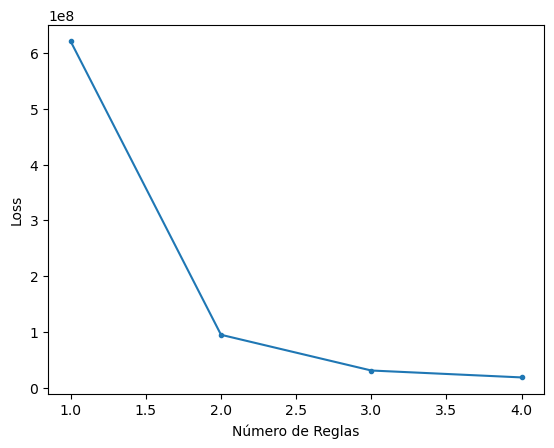

In [13]:
# gpu: cuda si nvidia, mps si mac, cpu si nada de eso
device= "mps"
n_in = 2 #atributos
n_out = 2 #salidas

x_todo = torch.tensor(atributos, device=torch.device(device), dtype=torch.float32)
target_tensor = torch.tensor(target, device=torch.device(device), dtype=torch.float32)


hist = {
    "reglas":[],
    "fis_st":[],
    "loss":[]
    }
# en regresión una regla por atributo?
for reglas in range(1,2*n_in+1):
    n_reglas = reglas 

    #atributos debe ser un pandas.Dataframe,
    #el target_oh debe ser un pandas.Dataframe 
    #se me fue y no cambie la interfaz
    fis,fis_str = CrearFISInicial("engine_temp",
                              atributos,
                              pd.DataFrame(target_tensor.cpu().numpy()),
                              n_reglas)

    # crear modelo temporal
    modelo = RLANFISBuilder() \
         .AddFIS(fis_str) \
         .AddInputs(n_in) \
         .AddOutputs(n_out) \
         .AddRules(n_reglas) \
         .AddMuStats(0.1,10,1e20)\
         .AddValMaxFails(20) \
         .AddOptimizador(LevenberMaquardtOpt)\
         .AddTipoProblema("regresion")\
         .AddDevice(device) \
         .Build() 
    
    #entrenar temporal
    historial_loss = train_nfs(
                        modelo, # modelo a usar
                        x_todo, target_tensor, # datos de entrenamiento
                        epochs=1000, # numero de iteraciones
                        tolerancia=1e-8, # error mínimo
                        debug=True
                )
    PrintLogLevel("WARNING",f"Reglas: {reglas}, Loss: {historial_loss[-1]:.9f}")
    hist["reglas"].append(reglas) 
    hist["fis_st"].append(fis_str)
    hist["loss"].append(historial_loss[-1])

# ploteamos
plt.plot(hist["reglas"], hist["loss"],".-")
plt.xlabel("Número de Reglas")
plt.ylabel("Loss")
plt.show()


## Creamos el modelo

### Entrenamiento

Cargando FIS
Entradas: 2 Salidas: 2 Reglas:3
sigma: torch.Size([2, 3])
centro: torch.Size([2, 3])
theta: torch.Size([3, 2])
LBM -> mps
[INFO] Inputs: torch.Size([719, 2]) , Outputs: torch.Size([719, 2])
[INFO] Epoch 0, Loss: 255246384.000000000
[INFO] Epoch 100, Loss: 18782272.000000000
[ERROR] [102] El modelo llego a las mu maximas 1.0E+20 >= 1.0E+20(True)
[ERROR] [102] con un loss de 18782272.000000000
[INFO] Loss: 18782272.0


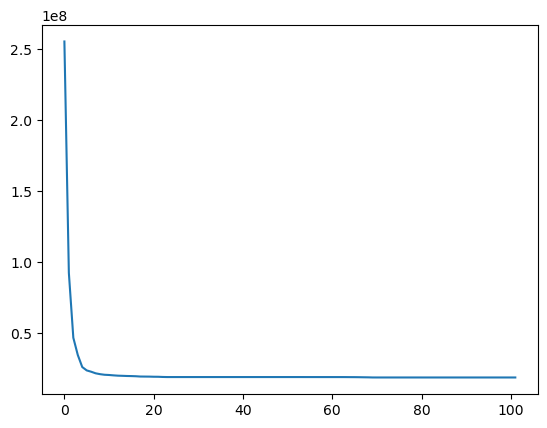

In [15]:
por_test =0.4 #60% entrenamiento, 20% test, 20% validacion
val_size = por_test/2
x_train,x_temp,y_train, y_temp = train_test_split(atributos,target,test_size=por_test) 
x_test, x_val, y_test, y_val = train_test_split(x_temp,y_temp,test_size=val_size)

#se ocupan que sean tensores
x_train_tensor = torch.from_numpy(x_train).float().to(torch.device(device))
x_test_tensor = torch.from_numpy(x_test).float().to(torch.device(device))
x_val_tensor = torch.from_numpy(x_val).float().to(torch.device(device))
y_train_tensor = torch.from_numpy(y_train).float().to(torch.device(device))
y_test_tensor = torch.from_numpy(y_test).float().to(torch.device(device))
y_val_tensor = torch.from_numpy(y_val).float().to(torch.device(device))


#mejores reglas
b_reglas = 3#hist["reglas"][np.argmin(hist["loss"])]

fis,fis_str = CrearFISInicial("engine",
                              pd.DataFrame(x_train),
                              pd.DataFrame(y_train_tensor.cpu().numpy()),
                              b_reglas)
# modelo
modelo = RLANFISBuilder() \
         .AddFIS(fis_str) \
         .AddInputs(n_in) \
         .AddOutputs(n_out) \
         .AddRules(b_reglas) \
         .AddMuStats(0.1,10,1e20)\
         .AddValMaxFails(20) \
         .AddOptimizador(LevenberMaquardtOpt)\
         .AddTipoProblema("regresion")\
         .AddDevice(device) \
         .Build() 


# entrenar
historial_loss = train_nfs(
                        modelo, # modelo a usar
                        x_train_tensor, y_train_tensor, # datos de entrenamiento
                        epochs=1000, # numero de iteraciones
                        tolerancia=1e-8, # error mínimo
                        debug=True
            )
PrintLogLevel("INFO",f"Loss: {historial_loss[-1]}")
plt.plot(historial_loss)
GuardarFIS("engine__final",fis,modelo)

## Graficar

In [16]:
from utils.funciones_auxiliares import PlotTraining

torch.Size([384, 2])
SSE = 1.033659E+07
MSE = 2.691820E+04
R = 0.9749062061309814
R^2 = 0.9502455592155457


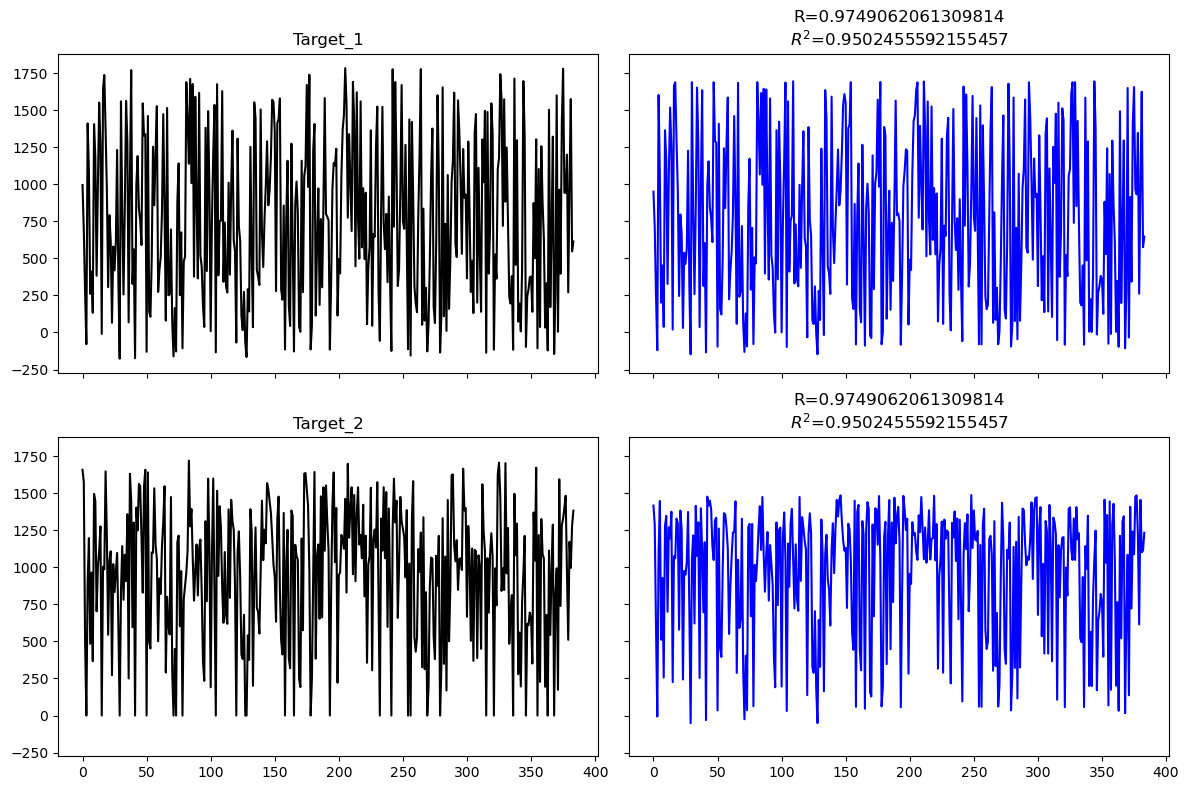

[INFO] SSE: 10336587.0
[INFO] R: 0.9749062061309814
[INFO] R2: 0.9502455592155457


In [17]:
# Regresión
yh = modelo(x_test_tensor)
print(yh.shape)

sse, r, r2 = PlotTraining(x_test_tensor,yh,y_test_tensor)

PrintLogLevel("INFO",f"SSE: {sse}")
PrintLogLevel("INFO",f"R: {r}")
PrintLogLevel("INFO",f"R2: {r2}")